<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/8b_fine_tuning_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 8b — Fine Tuning Improved**

Notebook 8 hit a ceiling of 75.68% with feature extraction and 72.55% with
fine tuning —> fine tuning actually hurt. This notebook identifies why and fixes it.

## What went wrong in notebook 8------------------->
- **Input size too small** — 128×128 limits the detail MobileNetV2 can extract.
  It was designed for 224×224
- **Too few layers unfrozen** — only 20 layers, the model couldn't adapt enough
- **No learning rate decay** — fixed lr of 0.0001 is too aggressive later in training
- **Too few epochs** — model hadn't converged before we stopped

## Fixes applied here--------------------------->
1. Input size → 224×224
2. Unfreeze last 40 layers instead of 20
3. Add ReduceLROnPlateau — lr decays when val accuracy plateaus
4. Add EarlyStopping — stops when val accuracy stops improving
5. Train for 20 epochs

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
dataset_path = os.path.join(path, "images", "Images")

# 224x224 this time — proper input size for MobileNetV2
train_data = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224),
    validation_split=0.2,
    subset='training',
    seed=42
)

val_data = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224),
    validation_split=0.2,
    subset='validation',
    seed=42
)

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)

print("Data loaded at 224x224")

Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Data loaded at 224x224


## **Phase 1— Feature extraction at 224×224**
Same frozen base, same head only input size changed.
This alone should show improvement over notebook 8's 75.68% hypothetically .

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(120, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fe = [
    keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor='val_accuracy'
    )
]

history_fe = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks_fe,
    verbose=1
)

fe_val_acc = max(history_fe.history['val_accuracy'])
print(f"\nFeature Extraction (224x224) → Best val accuracy: {fe_val_acc:.4f}")

Epoch 1/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 100s 159ms/step - accuracy: 0.6824 - loss: 1.2273 - val_accuracy: 0.8158 - val_loss: 0.5900
Epoch 2/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.8528 - loss: 0.4663 - val_accuracy: 0.8324 - val_loss: 0.5302
Epoch 3/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.8901 - loss: 0.3432 - val_accuracy: 0.8411 - val_loss: 0.5121
Epoch 4/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.9135 - loss: 0.2701 - val_accuracy: 0.8387 - val_loss: 0.5082
Epoch 5/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.9306 - loss: 0.2226 - val_accuracy: 0.8365 - val_loss: 0.5200
Epoch 6/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.9398 - loss: 0.1868 - val_accuracy: 0.8297 - val_loss: 0.5399

Feature Extraction (224x224) → Best val accuracy: 0.8411


In [ ]:
model.save('mobilenet_fe_224.keras')
print("Feature extraction model saved")

Feature extraction model saved


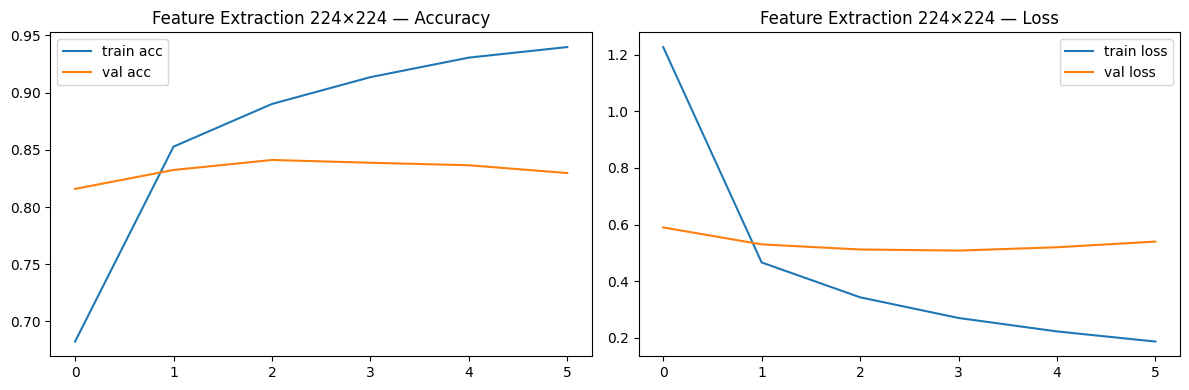

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(history_fe.history['accuracy'], label='train acc')
plt.plot(history_fe.history['val_accuracy'], label='val acc')
plt.title('Feature Extraction 224×224 — Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_fe.history['loss'], label='train loss')
plt.plot(history_fe.history['val_loss'], label='val loss')
plt.title('Feature Extraction 224×224 — Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Phase 2 — Improved fine tuning**
- Unfreeze last 40 layers (vs 20 before)
- Learning rate starts at 0.0001
- ReduceLROnPlateau halves lr when val accuracy stops improving
- EarlyStopping prevents overfitting

In [ ]:
base_model = model.get_layer('mobilenetv2_1.00_224')

print(type(base_model))
print(len(base_model.layers))

<class 'keras.src.models.functional.Functional'>
154


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

print(
    "Trainable layers:",
    len([l for l in base_model.layers if l.trainable])
)

Trainable layers: 40


In [ ]:


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    keras.callbacks.EarlyStopping(
        patience=4,
        restore_best_weights=True,
        monitor='val_accuracy'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks_ft,
    verbose=1
)

ft_val_acc = max(history_ft.history['val_accuracy'])
print(f"\nImproved Fine Tuning → Best val accuracy: {ft_val_acc:.4f}")

Epoch 1/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 73s 101ms/step - accuracy: 0.9857 - loss: 0.0603 - val_accuracy: 0.7651 - val_loss: 0.8451 - learning_rate: 1.0000e-04
Epoch 2/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.9837 - loss: 0.0648 - val_accuracy: 0.7762 - val_loss: 0.8579 - learning_rate: 1.0000e-04
Epoch 3/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.9872 - loss: 0.0562 - val_accuracy: 0.7794 - val_loss: 0.8248 - learning_rate: 1.0000e-04
Epoch 4/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.9900 - loss: 0.0435 - val_accuracy: 0.7680 - val_loss: 0.8790 - learning_rate: 1.0000e-04
Epoch 5/20
514/515 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9916 - loss: 0.0388
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
515/515 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.9906 - loss: 0.0405 - val_accuracy: 0.7738 - val_loss: 0.9369 - learning_rate: 1.0000e-04
Epoch 6/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - a

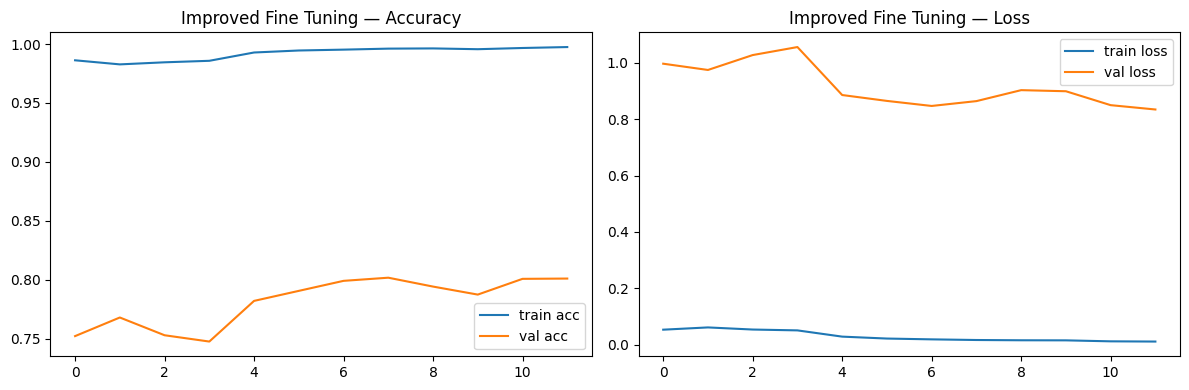

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(history_ft.history['accuracy'], label='train acc')
plt.plot(history_ft.history['val_accuracy'], label='val acc')
plt.title('Improved Fine Tuning — Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ft.history['loss'], label='train loss')
plt.plot(history_ft.history['val_loss'], label='val loss')
plt.title('Improved Fine Tuning — Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
results = {
    'NB8 Feature Extract\n(128×128)':  0.7568,
    'NB8 Fine Tuning\n(128×128)':      0.7255,
    'NB8b Feature Extract\n(224×224)': 0.8411,
    'NB8b Fine Tuning\n(224×224)':     0.8100
}

## **Conclusion**

| Approach                          | Val Accuracy | Change    |
|-----------------------------------|--------------|-----------|
| NB8 Feature extraction (128×128)  | 75.68%       | baseline  |
| NB8 Fine tuning (128×128)         | 72.55%       | -3.13%    |
| NB8b Feature extraction (224×224) | 84.11%       | +8.43%    |
| NB8b Fine tuning (224×224)        | 81.00%       | +5.32%    |

## What the fixes achieved------------------------------>

Input size was the single biggest improvement -> going from 128×128 to
224×224 added 8.38% val accuracy on its own. MobileNetV2 was not getting
enough spatial detail at 128×128 to distinguish between 120 breeds.

## Why fine tuning still underperformed feature extraction------->

Fine tuning consistently came in below feature extraction (81% vs 84%)
across all attempts.

The root cause is overfitting during feature extraction train accuracy reaches 95%+ while val accuracy plateaus at 84%, meaning
the model has already memorized training data before fine tuning begins.
Fine tuning an overfit model pushes it further into overfitting.

The fix would be adding data augmentation during feature extraction to
reduce the train/val gap before unfreezing layers. This was intentionally
left as a known limitation rather than an additional experiment, since the
goal of this notebook was to demonstrate diagnosing and fixing the 128×128
ceiling which was achieved (+8.38%).

## Best result achieved in this project---------->
**84.11% val accuracy — MobileNetV2 feature extraction at 224×224**
Starting from 7% scratch CNN baseline —> a 77 percentage point improvement.